## Import necessary libraries

In [18]:
import math
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.linear_model import LinearRegression , Ridge
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split,RandomizedSearchCV

## Importing data into notebook

In [19]:
df = pd.read_excel('premiums.xlsx')
print(df.shape)
df.head()

(50000, 13)


,Age,Gender,Region,Marital_status,Number Of Dependants,BMI_Category,Smoking_Status,Employment_Status,Income_Level,Income_Lakhs,Medical History,Insurance_Plan,Annual_Premium_Amount
0,26,Male,Northwest,Unmarried,0,Normal,No Smoking,Salaried,<10L,6,Diabetes,Bronze,9053
1,29,Female,Southeast,Married,2,Obesity,Regular,Salaried,<10L,6,Diabetes,Bronze,16339
2,49,Female,Northeast,Married,2,Normal,No Smoking,Self-Employed,10L - 25L,20,High blood pressure,Silver,18164
3,30,Female,Southeast,Married,3,Normal,No Smoking,Salaried,> 40L,77,No Disease,Gold,20303
4,18,Male,Northeast,Unmarried,0,Overweight,Regular,Self-Employed,> 40L,99,High blood pressure,Silver,13365


## Data cleaning - Checking for null values and duplicates

In [20]:
df.isna().sum()

Age                       0
Gender                    0
Region                    0
Marital_status            0
Number Of Dependants      0
BMI_Category              0
Smoking_Status           11
Employment_Status         2
Income_Level             13
Income_Lakhs              0
Medical History           0
Insurance_Plan            0
Annual_Premium_Amount     0
dtype: int64

In [21]:
df.dropna(inplace=True)
df.isna().sum()

Age                      0
Gender                   0
Region                   0
Marital_status           0
Number Of Dependants     0
BMI_Category             0
Smoking_Status           0
Employment_Status        0
Income_Level             0
Income_Lakhs             0
Medical History          0
Insurance_Plan           0
Annual_Premium_Amount    0
dtype: int64

In [22]:
df.duplicated().sum()
df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

## Converting column names to snake case

In [23]:
df.columns = df.columns.str.replace(' ','_').str.lower()
df.head(1)

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount
0,26,Male,Northwest,Unmarried,0,Normal,No Smoking,Salaried,<10L,6,Diabetes,Bronze,9053


## Quick statistics of numerical columns 

In [24]:
df.describe()

,age,number_of_dependants,income_lakhs,annual_premium_amount
count,49976.000000,49976.000000,49976.000000,49976.000000
mean,34.591764,1.711842,23.021150,15766.810189
std,15.000378,1.498195,24.221794,8419.995271
min,18.000000,-3.000000,1.000000,3501.000000
25%,22.000000,0.000000,7.000000,8607.750000
50%,31.000000,2.000000,17.000000,13928.000000
75%,45.000000,3.000000,31.000000,22273.500000
max,356.000000,5.000000,930.000000,43471.000000


From the above statistics of numerical values we can clearly see some outliers in the data for eg in the age section the max age is 356 which is clearly an outlier and in number_of_depedants we can see negative values and in income_lakhs this might be outlier or it is true but the value will make the data right skewed and it will cause in change in mean value from its actual value

## Treating outlier in age column

In [25]:
# lets consider age threshold as 100 
df[df.age>100].shape
df1 = df[df.age<100].copy()
df1.describe()

,age,number_of_dependants,income_lakhs,annual_premium_amount
count,49918.000000,49918.000000,49918.000000,49918.000000
mean,34.401839,1.712168,23.025141,15766.589286
std,13.681600,1.498324,24.227912,8419.137327
min,18.000000,-3.000000,1.000000,3501.000000
25%,22.000000,0.000000,7.000000,8608.000000
50%,31.000000,2.000000,17.000000,13928.000000
75%,45.000000,3.000000,31.000000,22272.000000
max,72.000000,5.000000,930.000000,43471.000000


## Treating outlier in number_of_dependencies column

In [26]:
# lets consider number_of_dependants threshold as abs of values 
df1[df1.number_of_dependants<0].shape
df1.number_of_dependants = abs(df1.number_of_dependants)
df1.describe()

,age,number_of_dependants,income_lakhs,annual_premium_amount
count,49918.000000,49918.000000,49918.000000,49918.000000
mean,34.401839,1.717617,23.025141,15766.589286
std,13.681600,1.492074,24.227912,8419.137327
min,18.000000,0.000000,1.000000,3501.000000
25%,22.000000,0.000000,7.000000,8608.000000
50%,31.000000,2.000000,17.000000,13928.000000
75%,45.000000,3.000000,31.000000,22272.000000
max,72.000000,5.000000,930.000000,43471.000000


## Treating outlier in income_lakhs column

In [27]:
Q1,Q3 = df.income_lakhs.quantile([0.25,0.85])
IQR = Q3-Q1
lower_bound = Q1-2*IQR
upper_bount = Q3+2*IQR
lower_bound,upper_bount

(-57.0, 103.0)

In [28]:
df2 = df1[df1.income_lakhs<upper_bount].copy()
df2.describe()

,age,number_of_dependants,income_lakhs,annual_premium_amount
count,49908.000000,49908.000000,49908.000000,49908.000000
mean,34.401579,1.717640,22.889897,15765.739641
std,13.681604,1.492032,22.170699,8418.674061
min,18.000000,0.000000,1.000000,3501.000000
25%,22.000000,0.000000,7.000000,8608.000000
50%,31.000000,2.000000,17.000000,13928.000000
75%,45.000000,3.000000,31.000000,22270.500000
max,72.000000,5.000000,100.000000,43471.000000


In [29]:
df2.shape

(49908, 13)

## Plotting Boxplot for checking for outliers if any

In [30]:
features = df.select_dtypes(include=['float64', 'int64']).columns
features

Index(['age', 'number_of_dependants', 'income_lakhs', 'annual_premium_amount'], dtype='object')

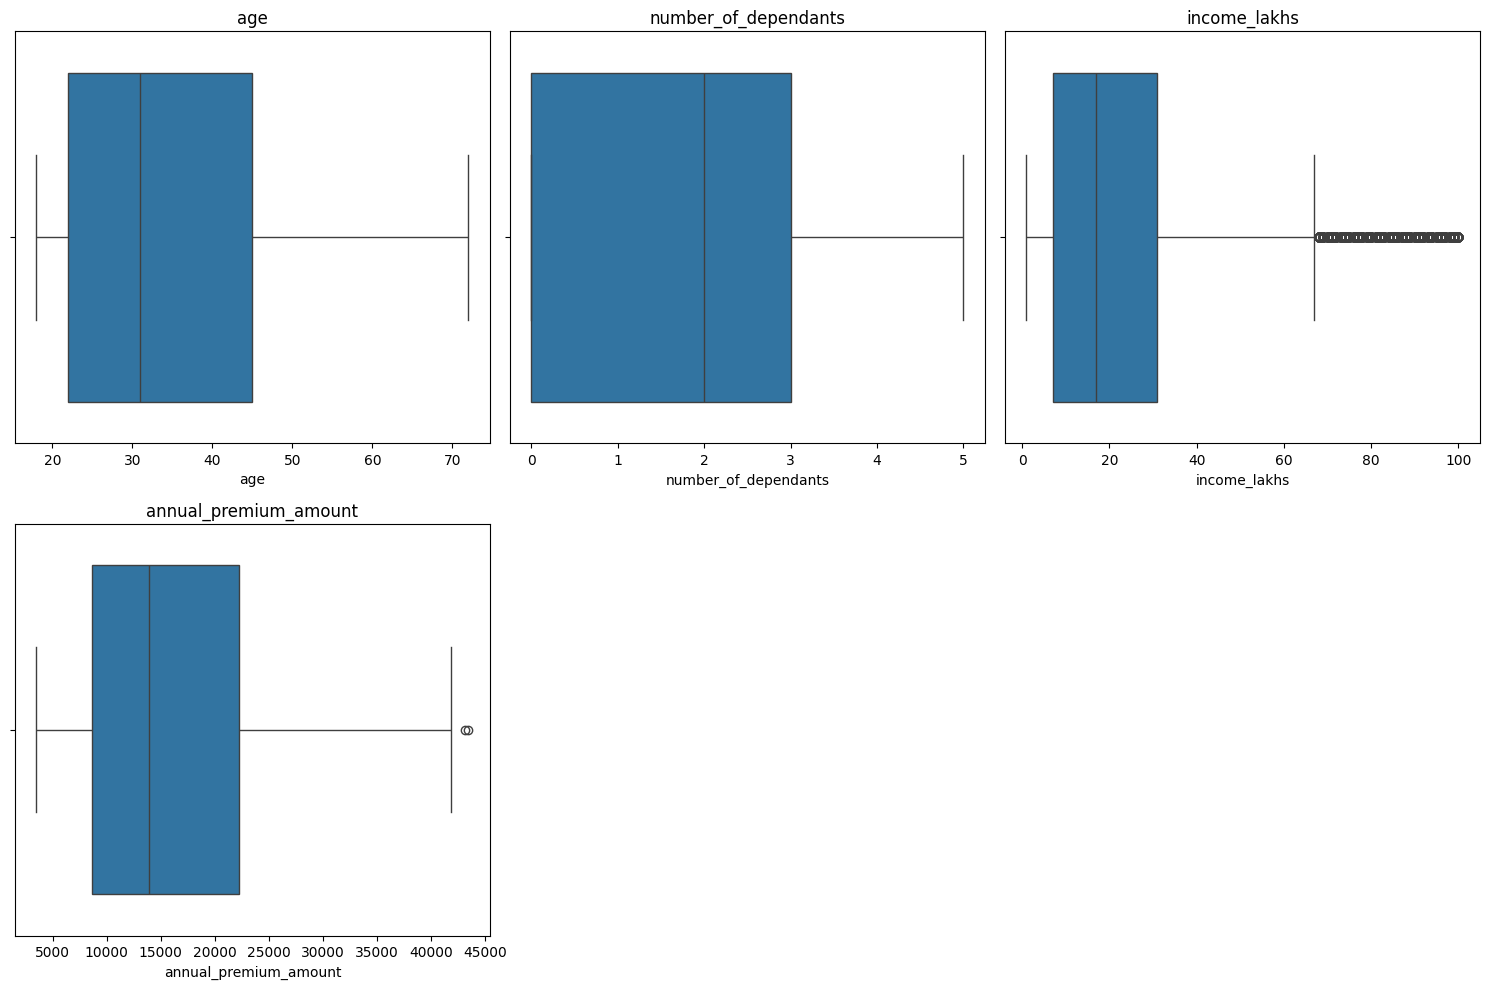

In [31]:
n = len(features)
cols = 3
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))
axes = axes.flatten()  # flatten in case of multiple rows

for i, feature in enumerate(features):
    sns.boxplot(x=df2[feature], ax=axes[i])
    axes[i].set_title(feature)

# Remove empty subplots if any
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## Plotting Scatter plot for checking patterns in data points

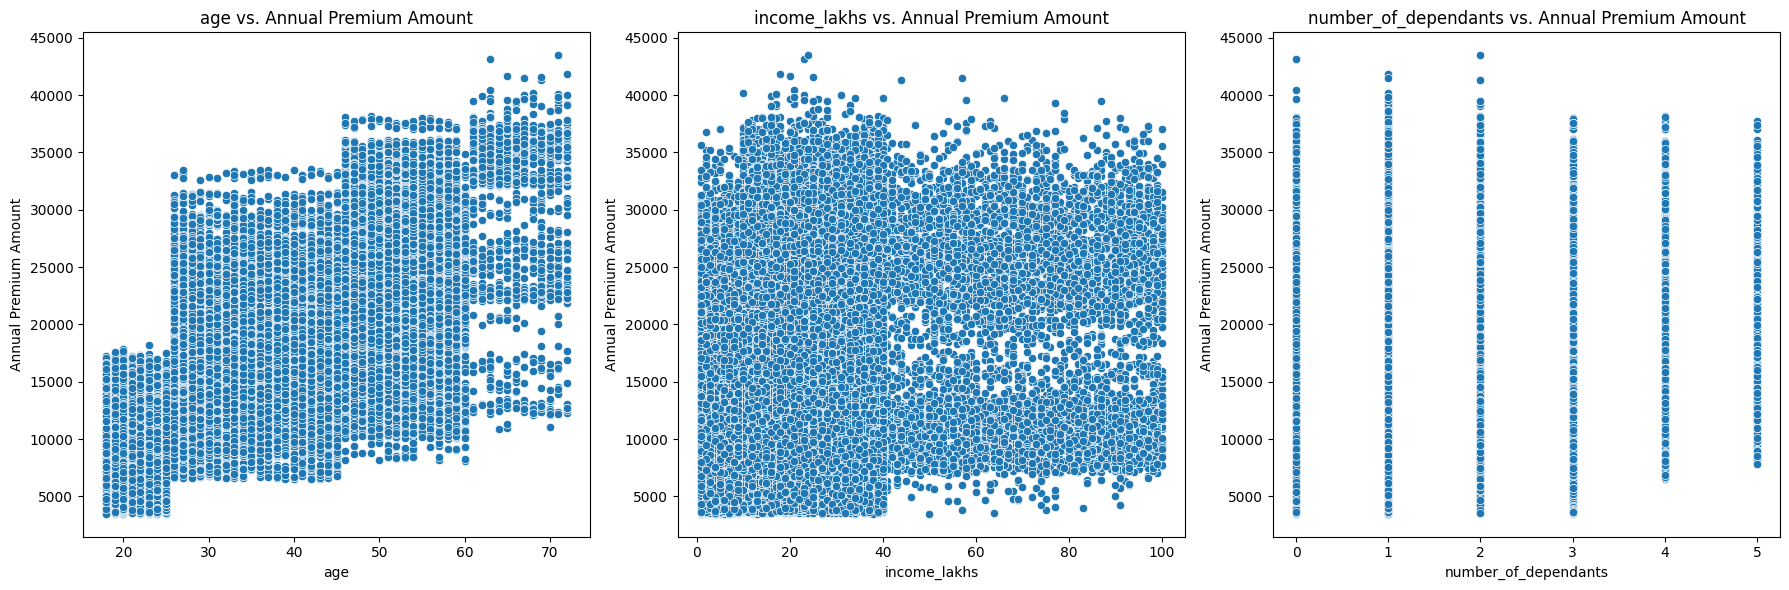

In [32]:
numeric_features = ['age', 'income_lakhs', 'number_of_dependants']

fig, axes = plt.subplots(1, len(numeric_features), figsize=(18, 6))  # Adjust figure size as necessary

for ax, column in zip(axes, numeric_features):
    sns.scatterplot(x=df2[column], y=df2['annual_premium_amount'], ax=ax)
    ax.set_title(f'{column} vs. Annual Premium Amount')
    ax.set_xlabel(column)
    ax.set_ylabel('Annual Premium Amount')

plt.tight_layout()  # Adjust layout
plt.show()

## Plotting histogram for checking patterns in data points

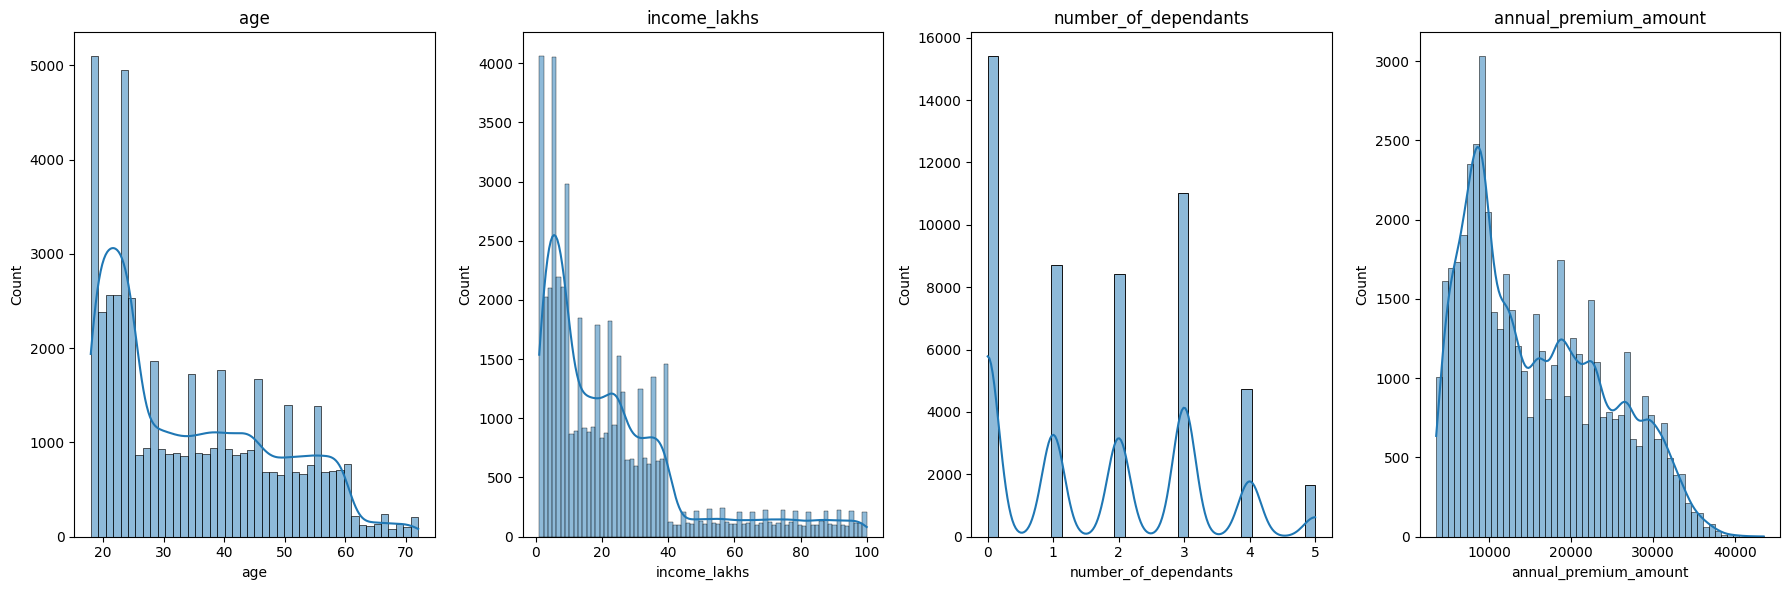

In [33]:
numeric_colums = ['age', 'income_lakhs', 'number_of_dependants','annual_premium_amount']

fig, axes = plt.subplots(1, len(numeric_colums), figsize=(18, 6))  # Adjust figure size as necessary

for ax, column in zip(axes, numeric_colums):
    sns.histplot(x=df2[column],kde=True,ax=ax)
    ax.set_title(f'{column}')
    ax.set_xlabel(column)

plt.tight_layout()  # Adjust layout
plt.show()

## Cleaning categorical data and visualizing it

In [35]:
categorical_features = df2.select_dtypes(include=['object']).columns
categorical_features

Index(['gender', 'region', 'marital_status', 'bmi_category', 'smoking_status',
       'employment_status', 'income_level', 'medical_history',
       'insurance_plan'],
      dtype='object')

In [36]:
for feature in categorical_features:
    print(f'{feature}: {df2[feature].unique()}')

gender: ['Male' 'Female']
region: ['Northwest' 'Southeast' 'Northeast' 'Southwest']
marital_status: ['Unmarried' 'Married']
bmi_category: ['Normal' 'Obesity' 'Overweight' 'Underweight']
smoking_status: ['No Smoking' 'Regular' 'Occasional' 'Smoking=0' 'Does Not Smoke'
 'Not Smoking']
employment_status: ['Salaried' 'Self-Employed' 'Freelancer']
income_level: ['<10L' '10L - 25L' '> 40L' '25L - 40L']
medical_history: ['Diabetes' 'High blood pressure' 'No Disease'
 'Diabetes & High blood pressure' 'Thyroid' 'Heart disease'
 'High blood pressure & Heart disease' 'Diabetes & Thyroid'
 'Diabetes & Heart disease']
insurance_plan: ['Bronze' 'Silver' 'Gold']


In [37]:
df2['smoking_status'] = df2['smoking_status'].replace({
    'Smoking=0':'No Smoking',
    'Does Not Smoke':'No Smoking',
    'Not Smoking':'No Smoking'
})

df2.smoking_status.unique()

array(['No Smoking', 'Regular', 'Occasional'], dtype=object)

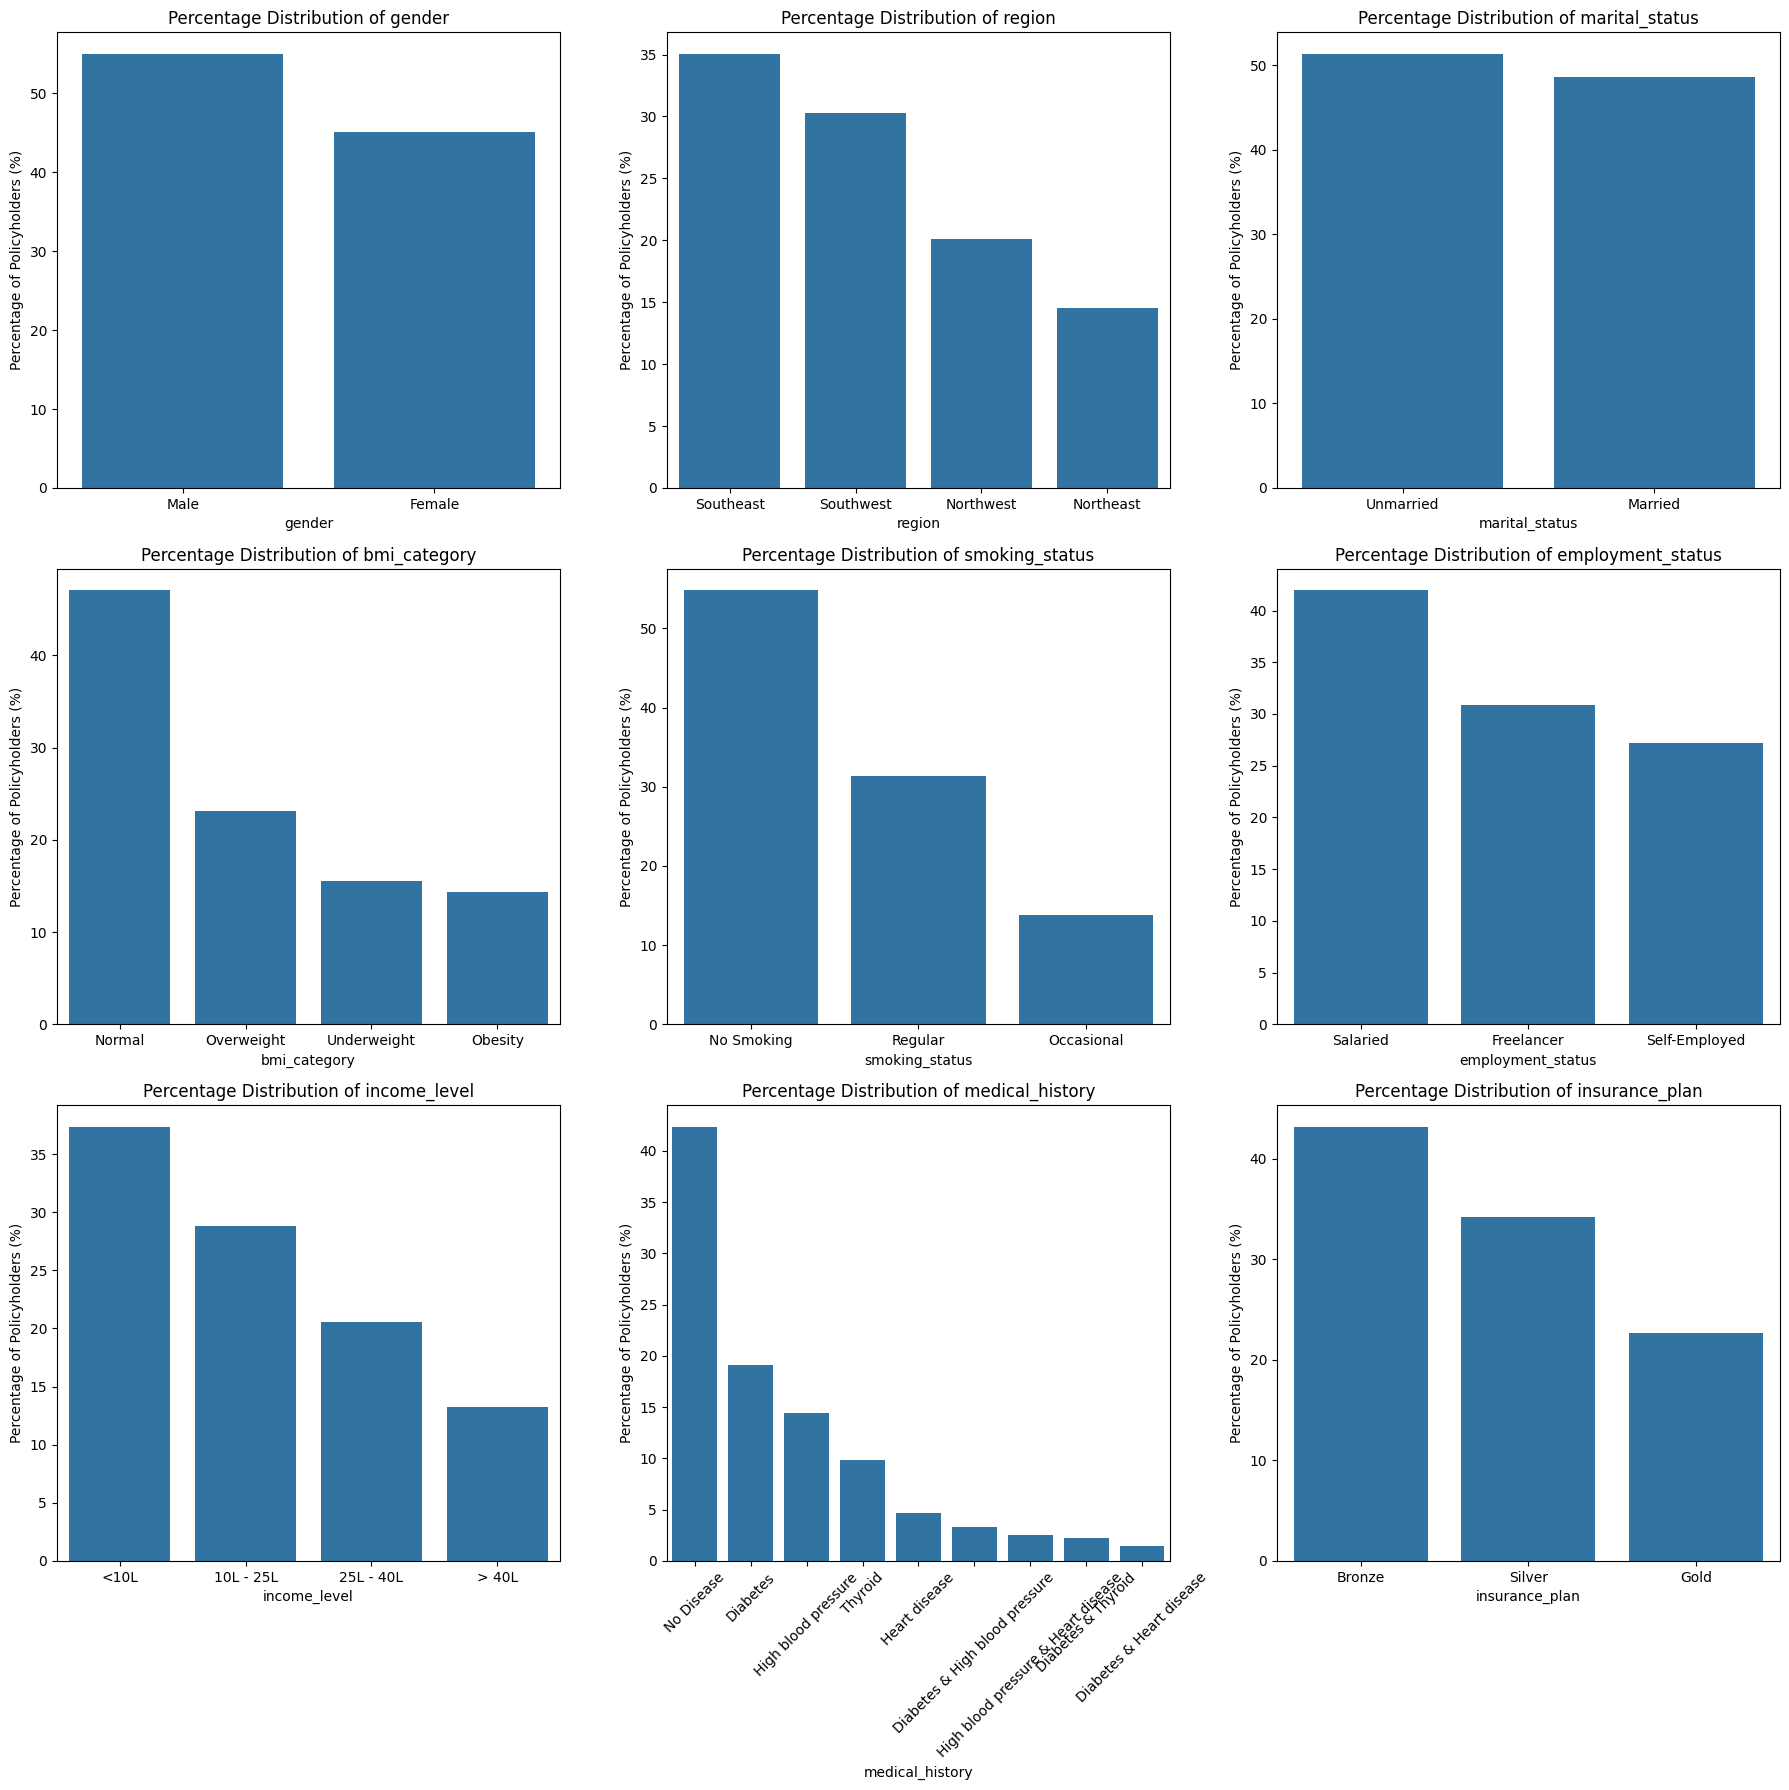

In [38]:
fig, axes = plt.subplots(3, 3, figsize=(18, 18))  # Adjust figure size as necessary
axes = axes.flatten()  # Flatten the 2D array of axes into 1D for easier iteration

for ax, column in zip(axes, categorical_features):
    # Calculate the percentage distribution of each category
    category_counts = df2[column].value_counts(normalize=True) * 100  # normalize=True gives the relative frequencies
    
    # Plotting the distribution using barplot
    if column == 'medical_history':
        ax.tick_params(axis='x', rotation=45)
    
    sns.barplot(x=category_counts.index, y=category_counts.values, ax=ax)
    ax.set_title(f'Percentage Distribution of {column}')
    ax.set_ylabel('Percentage of Policyholders (%)')
    ax.set_xlabel(column)  # Set xlabel to the column name for clarity

plt.tight_layout()  # Adjusts plot parameters for better fit in the figure window
plt.show()

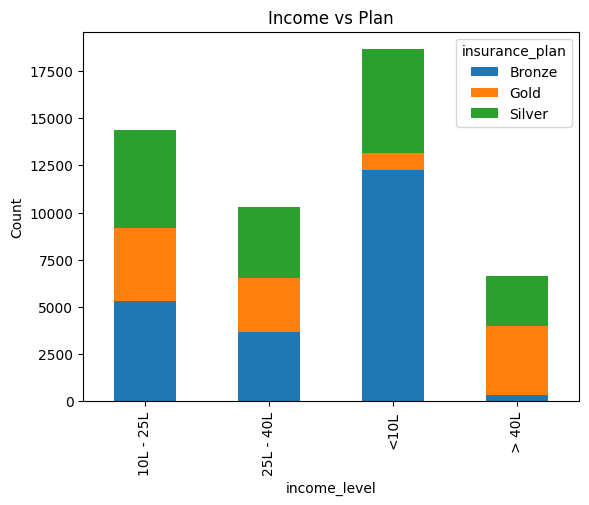

In [39]:
crosstab = pd.crosstab(df2.income_level,df2.insurance_plan)
crosstab
crosstab.plot(kind='bar', stacked=True)
plt.title('Income vs Plan')
plt.ylabel('Count')
plt.show()

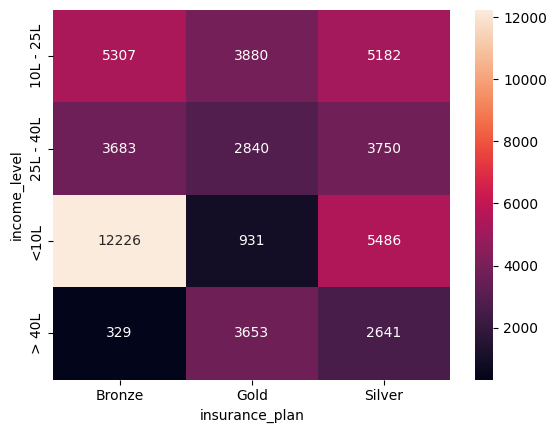

In [40]:
sns.heatmap(crosstab,annot=True,fmt='d')
plt.show()

## Feature Engineering - Calculate risk score for health history

In [41]:
risk_scores = {
    "diabetes": 6,
    "heart disease": 8,
    "high blood pressure":6,
    "thyroid": 5,
    "no disease": 0,
    "none":0
}

df2[['disease_1','disease_2']] = df2['medical_history'].str.split(' & ',expand=True).apply(lambda x: x.str.lower())

df2['disease_1'] = df2['disease_1'].fillna('none')
df2['disease_2'] = df2['disease_2'].fillna('none')

df2['total_risk_score'] = 0

for disease in ['disease_1', 'disease_2']:
    df2['total_risk_score']+= df2[disease].map(risk_scores)

min_score = df2['total_risk_score'].min()
max_score = df2['total_risk_score'].max()

df2['normalised_risk_score'] = (df2['total_risk_score'] - min_score) / (max_score - min_score)
df2.head(1)

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,disease_1,disease_2,total_risk_score,normalised_risk_score
0,26,Male,Northwest,Unmarried,0,Normal,No Smoking,Salaried,<10L,6,Diabetes,Bronze,9053,diabetes,none,6,0.428571


## Feature Engineering - Dropping unwanted columns and creating a new df

In [42]:
df3 = df2.drop(['medical_history','disease_1' , 'disease_2', 'total_risk_score'],axis=1)
df3.head()

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,insurance_plan,annual_premium_amount,normalised_risk_score
0,26,Male,Northwest,Unmarried,0,Normal,No Smoking,Salaried,<10L,6,Bronze,9053,0.428571
1,29,Female,Southeast,Married,2,Obesity,Regular,Salaried,<10L,6,Bronze,16339,0.428571
2,49,Female,Northeast,Married,2,Normal,No Smoking,Self-Employed,10L - 25L,20,Silver,18164,0.428571
3,30,Female,Southeast,Married,3,Normal,No Smoking,Salaried,> 40L,77,Gold,20303,0.000000
4,18,Male,Northeast,Unmarried,0,Overweight,Regular,Self-Employed,> 40L,99,Silver,13365,0.428571


## Feature Engineering - mapping maritial_satus column and converting it to numerical values

In [43]:
df3['insurance_plan'] = df3['insurance_plan'].map({'Bronze': 1, 'Silver': 2, 'Gold': 3})
df3.head(1)

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,insurance_plan,annual_premium_amount,normalised_risk_score
0,26,Male,Northwest,Unmarried,0,Normal,No Smoking,Salaried,<10L,6,1,9053,0.428571


In [44]:
df3['income_level'] = df3['income_level'].map({'<10L':1, '10L - 25L': 2, '25L - 40L':3, '> 40L':4})
df3.head(1)

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,insurance_plan,annual_premium_amount,normalised_risk_score
0,26,Male,Northwest,Unmarried,0,Normal,No Smoking,Salaried,1,6,1,9053,0.428571


In [45]:
nominal_cols = ['gender','region', 'marital_status', 'bmi_category', 'smoking_status', 'employment_status']
df3 = pd.get_dummies(df3, columns=nominal_cols, drop_first=True, dtype=int)
df3.head(3)

,age,number_of_dependants,income_level,income_lakhs,insurance_plan,annual_premium_amount,normalised_risk_score,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
0,26,0,1,6,1,9053,0.428571,1,1,0,0,1,0,0,0,0,0,1,0
1,29,2,1,6,1,16339,0.428571,0,0,1,0,0,1,0,0,0,1,1,0
2,49,2,2,20,2,18164,0.428571,0,0,0,0,0,0,0,0,0,0,0,1


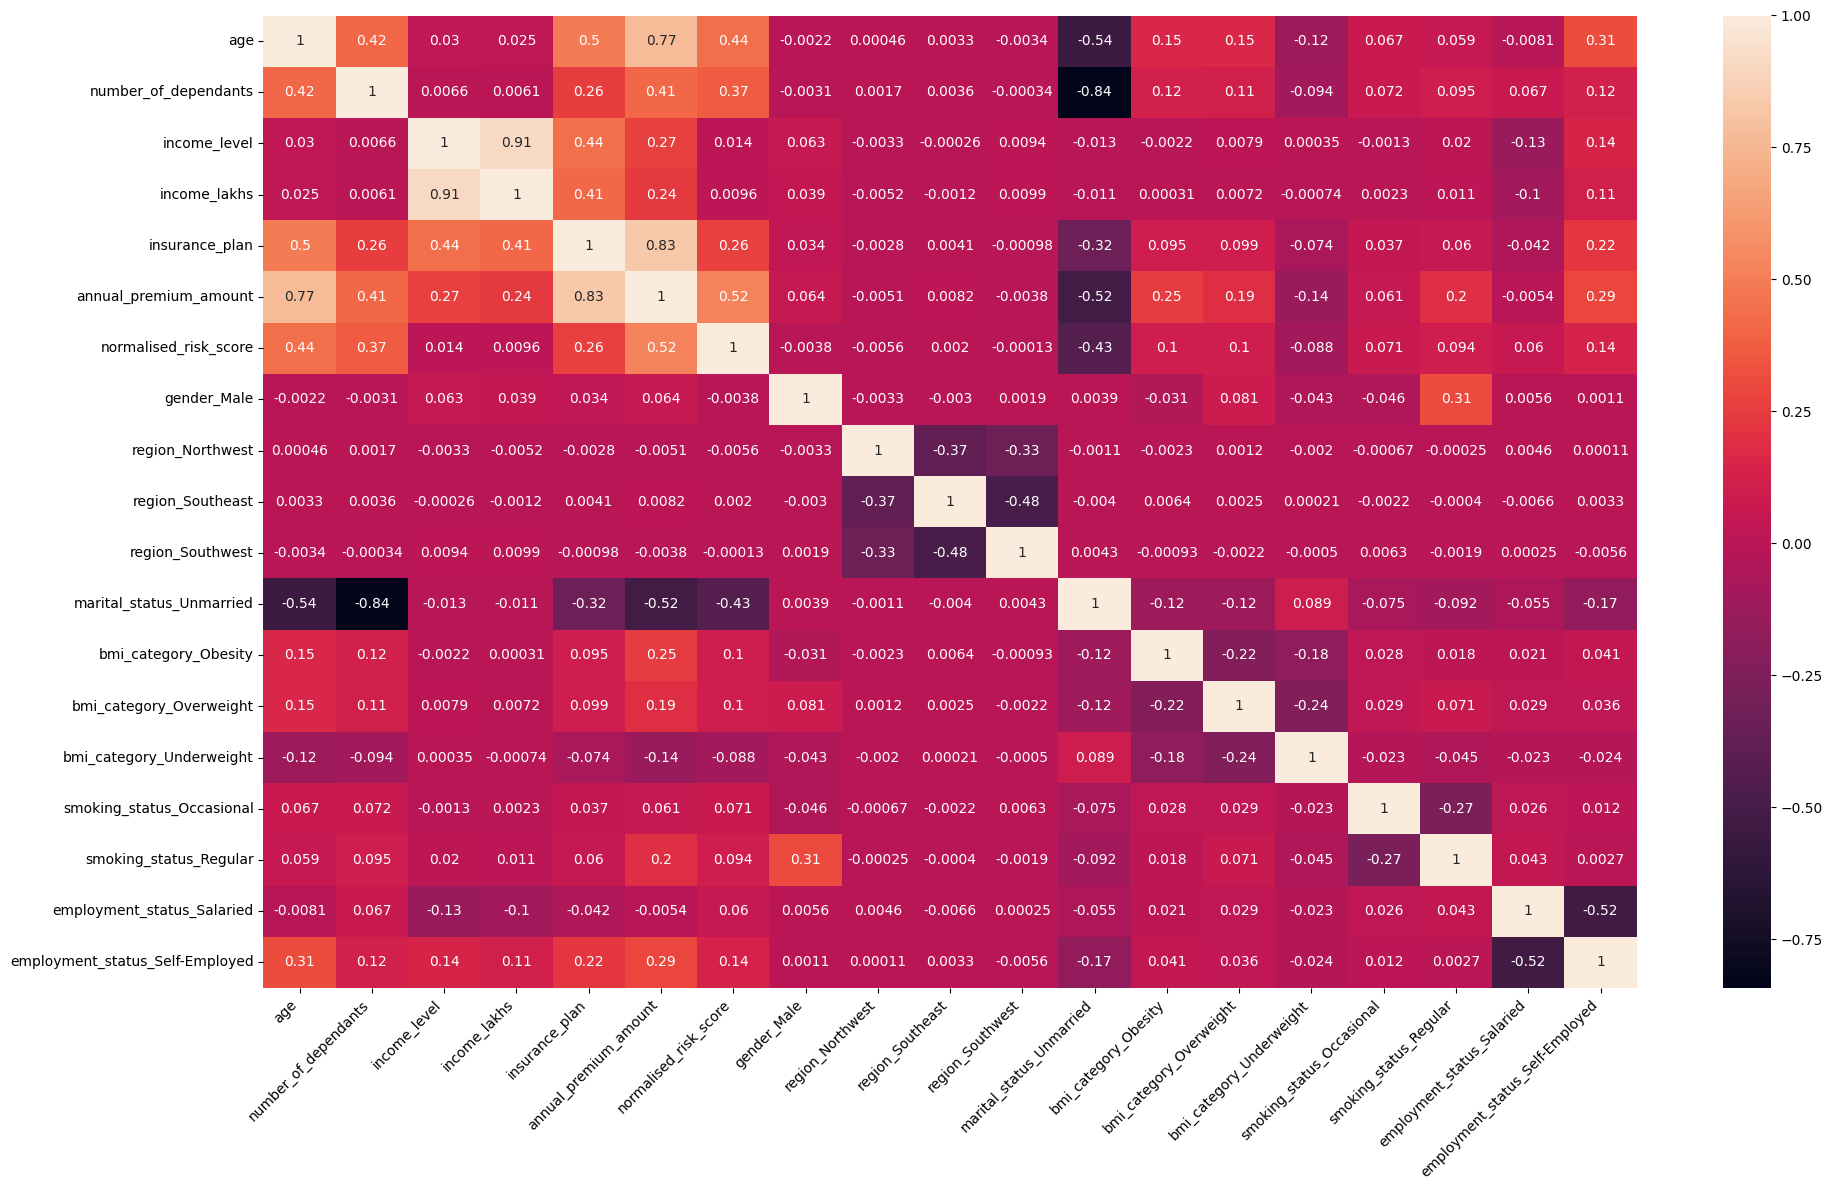

In [46]:
cm = df3.corr()

plt.figure(figsize=(20,12))
sns.heatmap(cm, annot=True)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## Feature Engineering - Finding correlation between features using Vif

In [47]:
X = df3.drop('annual_premium_amount',axis=1)
y = df3['annual_premium_amount']

scaler = MinMaxScaler()
columns = ['age','number_of_dependants','income_level','income_lakhs','insurance_plan']
X[columns] = scaler.fit_transform(X[columns])


In [48]:
def calculate_vif(data):
    vif_df = pd.DataFrame()
    vif_df['column'] = data.columns
    vif_df['score'] = [variance_inflation_factor(data.values,i)for i in range(data.shape[1])]
    return vif_df

In [49]:
calculate_vif(X)

,column,score
0,age,4.567634
1,number_of_dependants,4.534650
2,income_level,12.450675
3,income_lakhs,11.183367
4,insurance_plan,3.584752
5,normalised_risk_score,2.687610
6,gender_Male,2.421496
7,region_Northwest,2.102556
8,region_Southeast,2.922414
9,region_Southwest,2.670666


In [50]:
X = X.drop('income_level',axis=1)
calculate_vif(X)

,column,score
0,age,4.545825
1,number_of_dependants,4.526598
2,income_lakhs,2.480563
3,insurance_plan,3.445682
4,normalised_risk_score,2.687326
5,gender_Male,2.409980
6,region_Northwest,2.100789
7,region_Southeast,2.919775
8,region_Southwest,2.668314
9,marital_status_Unmarried,3.393718


## Model Training

In [51]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=10)

print("x train: ",X_train.shape)
print("x test: ",X_test.shape)
print("y train: ",y_train.shape)
print("y test: ",y_test.shape)

x train:  (34935, 17)
x test:  (14973, 17)
y train:  (34935,)
y test:  (14973,)


In [52]:
model_lr = LinearRegression()
model_lr.fit(X_train,y_train)
score = model_lr.score(X_test,y_test)
score

0.9280547230217837

In [53]:
model_rd = Ridge()
model_rd.fit(X_train,y_train)
score = model_rd.score(X_test,y_test)
score

0.9280541644640345

In [54]:
model_xgb = XGBRegressor()
model_xgb.fit(X_train,y_train)
score = model_xgb.score(X_test,y_test)
score

0.9809534549713135

In [60]:
from sklearn.metrics import r2_score
y_pred = model_xgb.predict(X_test)
r2_SCORE = r2_score(y_pred,y_test)
r2_SCORE

0.9806463718414307

In [ ]:
param_grid = {
    'n_estimators': [20, 40, 50],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 4, 5],
}
random_search = RandomizedSearchCV(model_xgb,param_grid,n_iter=10,cv=3,scoring='r2',random_state=42,n_jobs=-1)
random_search.fit(X_train,y_train)
random_search.best_score_
best_model = random_search.best_estimator_
random_search.best_params_

In [ ]:
feature_importance = best_model.feature_importances_

# Create a DataFrame for easier handling
coef_df = pd.DataFrame(feature_importance, index=X_train.columns, columns=['Coefficients'])

# Sort the coefficients for better visualization
coef_df = coef_df.sort_values(by='Coefficients', ascending=True)

# Plotting
plt.figure(figsize=(8, 4))
plt.barh(coef_df.index, coef_df['Coefficients'], color='steelblue')
plt.xlabel('Coefficient Value')
plt.title('Feature Importance in XGBoost')
plt.show()

In [ ]:
y_pred = best_model.predict(X_test)
residual = y_pred - y_test
residual_pct = residual*100/y_test
result_df = pd.DataFrame({
    'actual':y_test,
    'predicted':y_pred,
    'diff':residual,
    'diff_pct':residual_pct
})
result_df.head()

In [ ]:
sns.histplot(result_df,x='diff_pct')
plt.show()

In [ ]:
pct_threshold = 10
extreme_result_df  = result_df[abs(result_df.diff_pct)>pct_threshold]
extreme_result_df

In [ ]:
extreme_error_pct = extreme_result_df.shape[0]*100/result_df.shape[0]
extreme_error_pct

In [ ]:
result_df[abs(result_df.diff_pct)>50]

In [ ]:
extreme_error_df = X_test.loc[extreme_result_df.index]
extreme_error_df.head()

In [ ]:
for feature in X_test.columns:
    plt.figure(figsize=(10, 4))
    sns.histplot(extreme_error_df[feature], color='red', label='Extreme Errors', kde=True)
    sns.histplot(X_test[feature], color='blue', label='Overall', alpha=0.5, kde=True)
    plt.legend()
    plt.title(f'Distribution of {feature} for Extreme Errors vs Overall')
    plt.show()

In [ ]:
reverse_df = pd.DataFrame()
extreme_error_df['income_level'] = None
reverse_df[columns] = scaler.inverse_transform(extreme_error_df[columns])
reverse_df.head()

In [ ]:
reverse_df.describe()

In [ ]:
sns.histplot(reverse_df.age)

In [ ]:
reverse_df.age.quantile(0.97)